# Emotion Proxy-Label Pipeline

This notebook turns one session's raw recordings (heart-rate data, face
video, plant bioelectric voltage) into a per-window emotion label. Two
signal families feed two **independent** axes, crossed into a single label:

- **Valence** (`negative` / `neutral` / `positive`) — determined **only**
  by facial expression (HSEmotion `enet_b0_8_va_mtl`).
- **Arousal** (`calm` / `neutral` / `activated`) — determined **only** by
  heart-rate variability (RMSSD) and mean heart rate.
- **Emotion** (the crossed label) — five classes: `negative activated`,
  `negative calm`, `neutral`, `positive activated`, `positive calm`.

These labels are the training target for a downstream model that predicts
emotion from the plant signal alone.

There is no self-report in this study, so these are **proxy labels**, not
ground truth — our best reconstruction of what the participant likely felt,
each axis read from exactly one signal with no fusion step to second-guess.

**Scope note.** Each session is treated as one continuous recording; the
pipeline does not use any information about which video clip was playing
at a given time.

### The two data sources

| Source | Role in the label | Supported by |
|---|---|---|
| Facial expression (HSEmotion `enet_b0_8_va_mtl`) | **Sole** determinant of **valence**. The model's arousal output is exported for inspection (§4.9) but never read by the label rule. | Mollahosseini et al. (2019); Savchenko (2022); Soleymani et al. (2016) — facial expression outperformed a physiological signal (EEG) for continuous valence |
| RMSSD + mean HR (Polar H10) | **Sole** determinant of **arousal**; never decides valence. | Shaffer & Ginsberg (2017); Kreibig (2010). Ultra-short RMSSD alone is a contested arousal signal (Schippers et al., 2018; Gu et al., 2023) — see §4.12 |

### What this notebook does not claim

- This is a **proxy label**, not ground truth — no participant ever rated
  how they felt, so its accuracy is unknown.
- HRV never decides valence, and FER never decides arousal. The two axes
  are read from disjoint signals and never fused or checked against each
  other.
- Facial expression can be suppressed. A participant who felt something
  without showing it is labelled valence `"neutral"` — the label describes
  the face, not the inner state.
- This pipeline ignores stimulus/clip structure, so it cannot check whether
  different participants reacted the same way to the same moment.

### Pipeline overview

```
 events.jsonl ──┬─→ R-R intervals ──→ artefact correction (4.3) ──→ HRV features per window (4.5) ─┐
                │                                                                                    │
                └─→ plant_voltage ──→ measured sampling rate ──→ plant features per window (4.10)    │
                                                                                                       │
 video.mp4 ─────────→ MTCNN face detection ──→ HSEmotion (enet_b0_8_va_mtl) ──→ FER features / window (4.6)
                              │                                                                        │
                              ▼                                                                        ▼
                    valence direction (4.7, FER only)                     arousal level (4.7, HRV only)
                    negative / neutral / positive                         calm / neutral / activated
                              │                                                                        │
                              └───────────────────────────┬────────────────────────────────────────────┘
                                                            ▼
                                          label rule: quality gate → cross valence x arousal (4.8)
                                          → 5 classes: negative activated, negative calm, neutral,
                                            positive activated, positive calm → confidence (4.8)
                                                            │
                                                            ▼
                                      labelled_windows_overlapping.csv (inspection)
                                      labelled_windows_ml.csv (training, non-overlapping)
```


## 4.1 Configuration

Every parameter is set once, below, with a comment saying which source
justifies it — or **pragmatic**, meaning it's an engineering choice, not a
literature value. Change a pragmatic value and re-run from here; there is
no automated sensitivity sweep in this notebook.

Two choices worth knowing:

- **`WIN_S = 30`** (window length, seconds). Standard short-term HRV
  guidance recommends 5-minute windows (Task Force, 1996), which is far too
  coarse for a ~10-minute session. We use the *ultra-short-term* 30-second
  window that Baek et al. (2015) showed is the minimum needed to reliably
  approximate a 5-minute RMSSD value.
- **`K_TAU` / `AROUSAL_K_TAU` = 0.5.** Both label axes use a "neutral"
  deadband centered on the session's own median and scaled by its own
  spread (median absolute deviation) — same shape of rule, applied
  independently to `fer_valence` (valence) and `arousal_hrv` (arousal).
  `0.5` was chosen after `0.75` labelled most windows on both axes
  `neutral` on a real session; `0.5` yields more usable labels, at the cost
  of noisier per-window direction calls (§4.7).


In [1]:
import json, math, os, subprocess, sys, warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats as sp_stats
from scipy import signal as sp_signal

import neurokit2 as nk

try:
    import cv2
    CV2_OK = True
except ImportError:
    CV2_OK = False
    print("opencv-python not installed - FER on video will not be available")

try:
    from facenet_pytorch import MTCNN
    MTCNN_OK = True
except ImportError:
    MTCNN_OK = False
    print("facenet-pytorch not installed - FER on video will not be available")

try:
    from hsemotion_onnx.facial_emotions import HSEmotionRecognizer
    HSEMOTION_OK = True
except ImportError:
    HSEMOTION_OK = False
    print("hsemotion-onnx not installed - FER on video will not be available")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# ── Determinism ──────────────────────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)

# ══════════════════════════════════════════════════════════════════════════
# Window geometry
# ══════════════════════════════════════════════════════════════════════════
WIN_S = 30              # Baek et al. (2015): minimum window to reliably estimate 5-min RMSSD
STEP_S = 5              # analysis grid step (overlapping; inspection/plots only, see 4.9)
STEP_S_EXPORT = 30      # ML export grid step (== WIN_S -> non-overlapping windows, see 4.9)
FER_SAMPLE_HZ = 5       # pragmatic - frame sampling rate for face/HSEmotion inference
MTCNN_DETECT_SCALE = 0.5    # pragmatic - MTCNN searches a half-resolution copy of each frame
                             # (checked against full-res on real video: same detection rate,
                             # median box IoU 0.918 - see §4.6). Only the search is downscaled;
                             # HSEmotion always sees the full-resolution crop.
MTCNN_MIN_FACE_SIZE = 60    # pragmatic - these are seated, camera-facing recordings; the face
                             # is never smaller than this, so MTCNN can skip its finest pyramid
                             # scales (default is 20px)
MTCNN_BATCH_SIZE = 64        # pragmatic - sampled frames are detected in batches of this size
                              # rather than one at a time (~2x faster measured on real session
                              # video - see §4.6), chunked to keep memory bounded rather than
                              # batching an entire session's sampled frames at once

# ══════════════════════════════════════════════════════════════════════════
# Calibration (§4.7) - pragmatic unless noted
# ══════════════════════════════════════════════════════════════════════════
K_TAU = 0.5              # pragmatic - valence-threshold (deadband) multiplier, applied to fer_valence.
                         # History: started at 1.5 (labelled almost every window "neutral" on real
                         # sessions - too conservative to be useful downstream), lowered to 1.0, then to
                         # 0.75, then to 0.5 - a real session at 0.75 still labelled 15/20 ML-grid windows
                         # "neutral" on both axes; 0.5 keeps smaller deviations from a participant's own
                         # median as a real shift, at the cost of a noisier direction estimate per window.
AROUSAL_K_TAU = 0.5      # pragmatic - arousal-threshold (deadband) multiplier, applied to arousal_hrv
                         # (RMSSD + mean HR, no FER involved - see §4.7). Same role as K_TAU, same
                         # default value for symmetry between the two axes, but an independent knob:
                         # the two thresholds are read off two different signals and never interact.
MIN_ML_WINDOWS = 3      # pragmatic - median/MAD become unreliable with fewer non-overlapping windows

# ══════════════════════════════════════════════════════════════════════════
# Quality gates
# ══════════════════════════════════════════════════════════════════════════
HRV_ARTEFACT_FRACTION_MAX = 0.05   # §4.3 - if >5% of a window's beats were corrected, hrv_quality = "poor"
HRV_MIN_BEATS = 10                 # pragmatic - floor below which RMSSD is not meaningfully estimable
FER_COVERAGE_MIN = 0.5             # §4.6 - if face_coverage < 0.5, fer_quality = "poor"

# ══════════════════════════════════════════════════════════════════════════
# Confidence weights (§4.8) - all four pragmatic, sum to 1
# ══════════════════════════════════════════════════════════════════════════
W1_DIRECTION_CLARITY = 0.4   # |fer_valence - median| relative to tau - clarity of the valence signal
W2_FER_CONFIDENCE    = 0.3   # mean HSEmotion softmax confidence over the window
W3_FACE_COVERAGE     = 0.2   # fraction of sampled frames in the window with a detected face
W4_AROUSAL_CLARITY   = 0.1   # |arousal_hrv - median| relative to tau_arousal - the HRV-side analogue
                              # of W1. Not an agreement term: §4.7 no longer fuses HRV with FER arousal,
                              # so there is nothing left for the two channels to agree or disagree about.
assert abs((W1_DIRECTION_CLARITY + W2_FER_CONFIDENCE + W3_FACE_COVERAGE + W4_AROUSAL_CLARITY) - 1.0) < 1e-9

# ══════════════════════════════════════════════════════════════════════════
# Descriptive-only sanity range (NOT a filter - see §4.5)
# ══════════════════════════════════════════════════════════════════════════
RMSSD_NUNAN_RANGE_MS = (19.0, 75.0)   # Nunan et al. (2010), reproduced in Shaffer & Ginsberg (2017), Table 6

# ══════════════════════════════════════════════════════════════════════════
# Plant voltage (§4.10)
# ══════════════════════════════════════════════════════════════════════════
# Firmware nominal: 380 Hz internal sampling, decimated by an integer factor
# of 3 (380 // 100, truncated) -> a TRUE rate of 126.67 Hz, not the 100 Hz
# the firmware reports as "sampleRate" (arduino/plant_sensor_script.ino,
# SAMPLE_RATE / OUTPUT_RATE / DECIMATION_FACTOR). This is a provenance
# placeholder only: §4.10 measures the actual rate from the timestamps of
# every session and compares it against this value - it does not assume it.
PLANT_FS_NOMINAL_HZ = 380.0 / 3.01
PLANT_FS_TOLERANCE = 0.10             # pragmatic - real sessions measure ~117-120 Hz via
                                       # samples/span (~5-6% below nominal, consistent WiFi/
                                       # buffering overhead - not a per-session anomaly); 10%
                                       # still catches an unresolved order-of-magnitude
                                       # contradiction like the old 100-vs-126.67 Hz mismatch
PLANT_DEAD_VOLTAGE_THRESHOLD = 0.005  # volts, pragmatic
ADC_VREF = 3.3                        # ESP32 ADC reference (hardware spec, not a citation)
MAINS_HZ = 50.0                       # measured: a ~49-50Hz peak carries 66-73% of total signal
                                       # power on every real session checked - notched out of the
                                       # time-domain features below (not the spectral ones, which
                                       # need to see the real spectrum) before it is ever averaged in

# ══════════════════════════════════════════════════════════════════════════
# Session selection
# ══════════════════════════════════════════════════════════════════════════
# A driver can process every session headless by setting SESSION_DIR_OVERRIDE
# before this notebook runs. Otherwise the notebook falls back to the most
# recent real session under ./sessions. This notebook only ever processes
# real recorded data - there is no synthetic/mock fallback.
SESSIONS_ROOT = Path("../data/sessions")
_override = os.environ.get("SESSION_DIR_OVERRIDE")
if _override:
    SESSION_DIR = Path(_override)
    _available = None
else:
    _available = sorted(SESSIONS_ROOT.glob("*/session_meta.json")) if SESSIONS_ROOT.exists() else []
    if not _available:
        raise RuntimeError(f"No sessions found under {SESSIONS_ROOT.resolve()}. "
                            "Record a session with init_recording.ipynb first.")
    SESSION_DIR = _available[-1].parent

if _available:
    print("Available sessions:")
    for j, p in enumerate(_available):
        print(f"  [{j}] {p.parent.name}")

META_FILE = SESSION_DIR / "session_meta.json"
if META_FILE.exists():
    meta = json.loads(META_FILE.read_text(encoding="utf-8"))
    T0_MS = meta.get("t0_ms")
    BASELINE_S = meta.get("baseline_s", 0)
    PARTICIPANT_ID = meta.get("participant_id") or meta.get("proband_id") or SESSION_DIR.name
    SESSION_ID = meta.get("session_id", SESSION_DIR.name)
else:
    meta = {}
    T0_MS = None
    BASELINE_S = 30
    PARTICIPANT_ID = SESSION_DIR.name
    SESSION_ID = SESSION_DIR.name

EVENT_STORE = SESSION_DIR / "events.jsonl"
FER_STORE   = SESSION_DIR / "fer_events_mtcnn.jsonl"   # own cache; NOT the old Haar-cascade fer_events.jsonl
VIDEO_FILE  = SESSION_DIR / "video.mp4"
OUT_OVERLAP_CSV = SESSION_DIR / "labelled_windows_overlapping.csv"
OUT_ML_CSV       = SESSION_DIR / "labelled_windows_ml.csv"

SESSION_DIR.mkdir(parents=True, exist_ok=True)
if not EVENT_STORE.exists():
    raise RuntimeError(
        f"No events.jsonl found in {SESSION_DIR}. This notebook only processes real "
        "recorded sessions - run init_recording.ipynb first, or point SESSION_DIR_OVERRIDE "
        "at an existing session folder.")

print(f"\nSession folder      : {SESSION_DIR.resolve()}")
print(f"Session ID          : {SESSION_ID}")
print(f"Participant ID      : {PARTICIPANT_ID}")
print(f"Event store present : {EVENT_STORE.exists()}")
print(f"Video present       : {VIDEO_FILE.exists()}")


Session folder      : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions\2026-07-06_19-14_proband_13
Session ID          : 2026-07-06_19-14_proband_13
Participant ID      : proband_13
Event store present : True
Video present       : True


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# Provenance block
# ══════════════════════════════════════════════════════════════════════════
def _pkg_version(mod_name):
    try:
        m = __import__(mod_name)
        return getattr(m, "__version__", "unknown")
    except Exception:
        return "not installed"

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=Path.cwd(), stderr=subprocess.DEVNULL
    ).decode().strip()
except Exception:
    GIT_COMMIT = "n/a (not a git repository or git unavailable)"

print("=" * 72)
print("PROVENANCE")
print("=" * 72)
print(f"Run timestamp (UTC) : {datetime.now(timezone.utc).isoformat()}")
print(f"Git commit          : {GIT_COMMIT}")
print(f"Random seed         : {SEED}")
print(f"Session             : {SESSION_ID}")
print(f"Participant         : {PARTICIPANT_ID}")
print("Package versions:")
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "seaborn", "neurokit2",
            "cv2", "onnxruntime"]:
    print(f"  {pkg:<15}: {_pkg_version(pkg)}")
print("=" * 72)

PROVENANCE
Run timestamp (UTC) : 2026-07-15T18:21:05.923515+00:00
Git commit          : 4a48c4b898007598132663b181aaff669128d3b3
Random seed         : 42
Session             : 2026-07-06_19-14_proband_13
Participant         : proband_13
Package versions:
  numpy          : 2.4.4
  pandas         : 2.3.3
  scipy          : 1.17.1
  matplotlib     : 3.10.8
  seaborn        : 0.13.2
  neurokit2      : 0.2.13
  cv2            : 4.13.0
  onnxruntime    : 1.26.0


## 4.2 Load & validate data

`events.jsonl` holds one JSON object per line (`ts`, `sensor`, value). Real
files can contain corrupted or malformed lines, so the loader tries the
whole file as one JSON value, then line-by-line, then a per-line scan for
concatenated objects — recovering what can be recovered.

Before anything else we run hard checks: required sensors must be present,
timestamps must not jump backwards beyond a small tolerance, and the
session duration must be physically plausible. A pipeline that runs on
broken input and produces a confident-looking answer is worse than one
that stops and says why.

**Hardware note.** The Polar H10 chest strap (source of `hr_rr`) is
validated against reference ECG: 99.4% signal quality and r = 0.997 against
an ECG Holter (Gilgen-Ammann et al., 2019), with strong HRV-specific
agreement (Schaffarczyk et al., 2022).


In [3]:
def load_events(path):
    # Robust JSONL loader: whole-file JSON, then line-by-line, then
    # multi-object-per-line recovery. Skips only lines that truly cannot be
    # parsed by any of these strategies.
    if not Path(path).exists():
        return []
    text = Path(path).read_text(encoding="utf-8")
    if not text.strip():
        return []
    try:
        data = json.loads(text)
        if isinstance(data, list):
            return [d for d in data if isinstance(d, dict)]
        return [data] if isinstance(data, dict) else []
    except json.JSONDecodeError:
        pass

    rows = []
    decoder = json.JSONDecoder()
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict):
                rows.append(obj); continue
            if isinstance(obj, list):
                rows.extend([o for o in obj if isinstance(o, dict)]); continue
            continue
        except json.JSONDecodeError:
            pass
        idx, L = 0, len(line)
        while idx < L:
            try:
                obj, end = decoder.raw_decode(line, idx)
                idx = end
                while idx < L and line[idx].isspace():
                    idx += 1
                if isinstance(obj, dict):
                    rows.append(obj)
                elif isinstance(obj, list):
                    rows.extend([o for o in obj if isinstance(o, dict)])
            except json.JSONDecodeError:
                break
    return rows


events = load_events(EVENT_STORE)
if not events:
    raise RuntimeError(f"No events could be loaded from {EVENT_STORE}.")
print(f"Events loaded (raw) : {len(events)}")

Events loaded (raw) : 90634


In [4]:
def validate_session(events, meta, video_present):
    # Hard checks. Raises RuntimeError with a clear message on failure;
    # returns a list of non-fatal warning strings otherwise.
    warnings_out = []
    by_sensor = {}
    for e in events:
        by_sensor.setdefault(e.get("sensor"), []).append(e)

    required = {"hr_rr", "plant_voltage"}
    missing = required - set(by_sensor)
    if missing:
        raise RuntimeError(f"Required sensor(s) missing from events.jsonl: {sorted(missing)}")
    if not video_present:
        warnings_out.append("No video.mp4 - facial expression (FER) will be unavailable; "
                             "every window will be excluded for missing_data (see §4.8).")

    for sensor, rows in by_sensor.items():
        ts = np.array([r["ts"] for r in rows if "ts" in r], dtype=np.int64)
        if ts.size < 2:
            continue
        backwards = np.diff(ts) < 0
        frac_backwards = backwards.mean()
        if frac_backwards > 0.01:
            raise RuntimeError(
                f"Sensor '{sensor}' has {backwards.sum()} out-of-order timestamps "
                f"({100*frac_backwards:.1f}% of samples) - stream is not usable.")
        elif backwards.any():
            warnings_out.append(f"Sensor '{sensor}': {backwards.sum()} minor out-of-order "
                                 f"timestamp(s) ({100*frac_backwards:.2f}%), tolerated.")

    all_ts = np.array([e["ts"] for e in events if "ts" in e], dtype=np.int64)
    duration_s = (all_ts.max() - all_ts.min()) / 1000.0
    if duration_s <= 10:
        raise RuntimeError(f"Session duration ({duration_s:.1f}s) is implausibly short (<=10s).")
    if duration_s > 3600:
        raise RuntimeError(f"Session duration ({duration_s:.1f}s) is implausibly long (>1h) - "
                            "check t0_ms / clock source.")
    return warnings_out, duration_s, all_ts.min(), all_ts.max()


_warnings, SESSION_DURATION_S, _t_min, _t_max = validate_session(events, meta, VIDEO_FILE.exists())
for w in _warnings:
    print(f"WARNING: {w}")

if T0_MS is None:
    T0_MS = int(_t_min)
SESSION_T1_MS = int(_t_max)

print(f"\nSession start (T0)  : {T0_MS}")
print(f"Session end          : {SESSION_T1_MS}")
print(f"Session duration     : {SESSION_DURATION_S:.1f} s")


Session start (T0)  : 1783358098516
Session end          : 1783358698649
Session duration     : 600.1 s


In [5]:
# ── Data-inventory table ────────────────────────────────────────────────
_by_sensor = Counter(e.get("sensor") for e in events)
_video_fps = _video_frames = np.nan
if VIDEO_FILE.exists() and CV2_OK:
    _cap = cv2.VideoCapture(str(VIDEO_FILE))
    _video_fps = _cap.get(cv2.CAP_PROP_FPS)
    _video_frames = _cap.get(cv2.CAP_PROP_FRAME_COUNT)
    _cap.release()

inventory = pd.DataFrame(
    [{"sensor": s, "n_events": n} for s, n in sorted(_by_sensor.items())]
)
print("Event counts per sensor:")
print(inventory.to_string(index=False))
print()
print(f"Session duration   : {SESSION_DURATION_S:.1f} s")
print(f"Baseline duration  : {BASELINE_S} s")
print(f"Video FPS          : {_video_fps}")
print(f"Video frame count  : {_video_frames}")

Event counts per sensor:
       sensor  n_events
 camera_frame     17060
          co2      1430
        hr_rr       723
        phase         2
plant_voltage     71419

Session duration   : 600.1 s
Baseline duration  : 30 s
Video FPS          : 30.0
Video frame count  : 17101.0


## 4.3 R-R interval preprocessing

The Polar H10 reports the time between heartbeats (the "R-R interval").
A single mis-detected beat corrupts every HRV measure computed from it —
Shaffer & Ginsberg (2017) note the resulting bias can eclipse typical
psychophysiological effect sizes. Artefact correction must run **before**
any HRV number is computed.

We use the beat-classification algorithm of Lipponen & Tarvainen (2019)
("Kubios" method) via NeuroKit2 (Makowski et al., 2021). It flags each
interval as normal, ectopic, missed, extra, or long/short, and corrects
the series accordingly.

Correction runs **per window**, giving us directly the fraction of each
window's beats that needed correction — the number the quality gate in
§4.5 needs. The cell below also runs the same check once across the full
session as a summary, with a before/after plot.


Session-wide artefact summary (descriptive only - the label rule uses per-window correction):
  ectopic   :     0  (0.00% of 723 beats)
  missed    :     0  (0.00% of 723 beats)
  extra     :     0  (0.00% of 723 beats)
  longshort :     2  (0.28% of 723 beats)
  any category : 0.28% of beats flagged


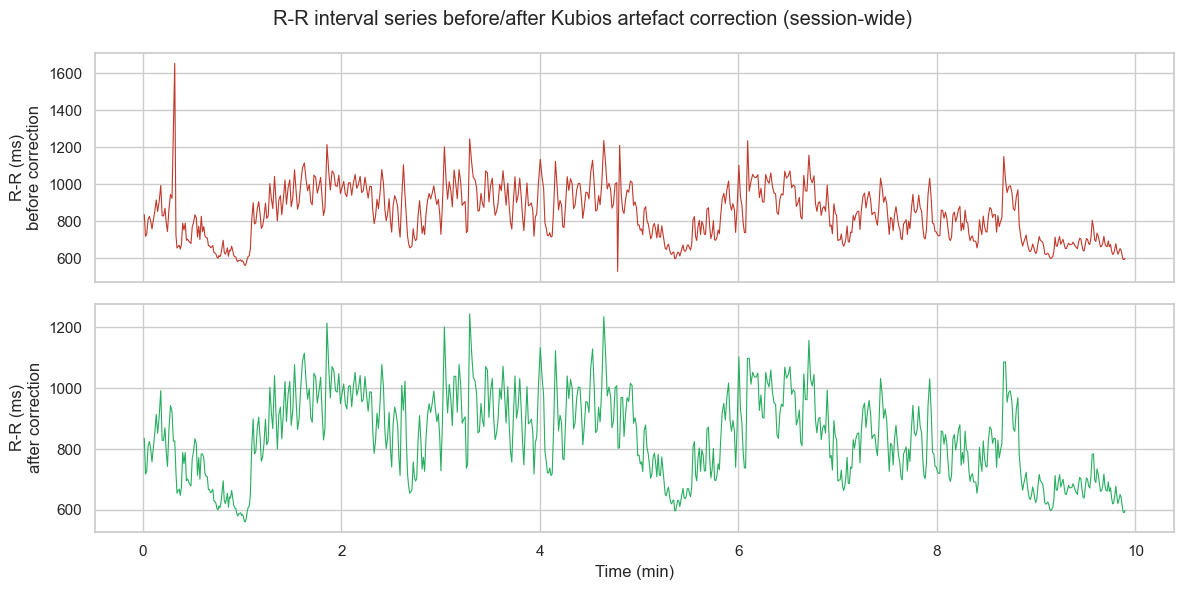

In [6]:
def correct_rr_series(rr_ms):
    # Runs the Lipponen & Tarvainen (2019) "Kubios" beat correction on one
    # array of R-R intervals (ms). Returns (corrected_rr_ms, artefact_fraction,
    # counts_by_category). intervals_to_peaks() turns the RR series into a
    # synthetic peak train (as if sampled at 1000 Hz) because signal_fixpeaks
    # operates on peak positions, not directly on intervals.
    rr_ms = np.asarray(rr_ms, dtype=float)
    n = rr_ms.size
    empty_counts = {"ectopic": 0, "missed": 0, "extra": 0, "longshort": 0}
    if n < 4:
        return rr_ms, 0.0, empty_counts
    peaks = nk.intervals_to_peaks(rr_ms, sampling_rate=1000)
    try:
        info, peaks_clean = nk.signal_fixpeaks(peaks, sampling_rate=1000, method="Kubios")
    except Exception:
        return rr_ms, 0.0, empty_counts
    counts = {k: len(info.get(k, [])) for k in empty_counts}
    flagged_idx = set()
    for k in empty_counts:
        flagged_idx.update(np.asarray(info.get(k, [])).astype(int).tolist())
    frac = len(flagged_idx) / max(1, n)
    rr_corrected = np.diff(np.asarray(peaks_clean, dtype=float))   # ms, since sampling_rate=1000
    return rr_corrected, frac, counts


rr_events = sorted([e for e in events if e.get("sensor") == "hr_rr"], key=lambda e: e["ts"])
if not rr_events:
    raise RuntimeError("No hr_rr events - Polar H10 R-R data missing")
_rr_all = np.array([e["value"] for e in rr_events], dtype=float)

_rr_corrected_all, _frac_all, _counts_all = correct_rr_series(_rr_all)
print("Session-wide artefact summary (descriptive only - the label rule uses per-window correction):")
_total = _rr_all.size
for k, v in _counts_all.items():
    print(f"  {k:<10}: {v:>5}  ({100*v/max(1,_total):.2f}% of {_total} beats)")
print(f"  any category : {100*_frac_all:.2f}% of beats flagged")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(np.cumsum(_rr_all) / 1000 / 60, _rr_all, color="#c0392b", lw=0.8)
axes[0].set_ylabel("R-R (ms)\nbefore correction")
axes[1].plot(np.cumsum(_rr_corrected_all) / 1000 / 60, _rr_corrected_all, color="#27ae60", lw=0.8)
axes[1].set_ylabel("R-R (ms)\nafter correction")
axes[1].set_xlabel("Time (min)")
fig.suptitle("R-R interval series before/after Kubios artefact correction (session-wide)")
plt.tight_layout(); plt.show()

### Window generation

Every window is a fixed-length slice `[start, start + WIN_S)` of the
continuous session. Two grids are built from the same session bounds:

- the **analysis grid** (`STEP_S = 5` s step) overlaps by 83% and exists only
  for the inspection plots in Section 4.11 and the `labelled_windows_overlapping.csv`
  export;
- the **ML grid** (`STEP_S_EXPORT = WIN_S`, i.e. no overlap) is the one used
  for calibration (Section 4.7) and for training data (Section 4.9), because
  overlapping windows share up to 83% of their raw samples and are not
  independent observations.

In [7]:
def build_windows(t0_ms, t1_ms, win_s, step_s):
    win_ms, step_ms = int(win_s * 1000), int(step_s * 1000)
    starts = []
    s = t0_ms
    while s + win_ms <= t1_ms:
        starts.append(s)
        s += step_ms
    return [(a, a + win_ms) for a in starts]


ANALYSIS_WINDOWS = build_windows(T0_MS, SESSION_T1_MS, WIN_S, STEP_S)
ML_WINDOWS = build_windows(T0_MS, SESSION_T1_MS, WIN_S, STEP_S_EXPORT)

print(f"Analysis grid (overlapping, step={STEP_S}s): {len(ANALYSIS_WINDOWS)} windows")
print(f"ML grid (non-overlapping, step={STEP_S_EXPORT}s): {len(ML_WINDOWS)} windows")

if len(ML_WINDOWS) < MIN_ML_WINDOWS:
    raise RuntimeError(
        f"Session yields only {len(ML_WINDOWS)} non-overlapping window(s); "
        f"need at least {MIN_ML_WINDOWS} for the median/MAD calibration in §4.7 to be meaningful.")

Analysis grid (overlapping, step=5s): 115 windows
ML grid (non-overlapping, step=30s): 20 windows


## 4.5 HRV features per window

For every window we compute **RMSSD** (the primary time-domain HRV
measure), **mean HR**, **SDNN** and **pNN50** (descriptive only, not used
in the label rule), and **n_beats**.

**Caveats, stated plainly:**

- Ultra-short-term values are not interchangeable with 5-min or 24-h
  values (Shaffer & Ginsberg, 2017) — a 30-second RMSSD is a different
  quantity, statistically, from what most HRV literature reports.
- Respiration was not recorded. Shifts in breathing change RMSSD without
  changing vagal tone (Shaffer & Ginsberg, 2017) — an uncontrolled
  confounder in every value below.
- RMSSD is never used for valence direction: the literature is
  inconsistent on whether it even tracks valence at all (Kreibig, 2010;
  Schneider et al., 2025), and Schippers et al. (2018), using the same
  30-second-window/IAPS design as this notebook, found no RMSSD difference
  between positive and negative induction.

`rmssd_outside_norm_range` flags windows outside the 19-75 ms range Nunan
et al. (2010) report as typical — descriptive only, **not** an exclusion
filter. The actual quality gate is the per-beat artefact fraction from
§4.3.


In [8]:
def compute_hrv_features_for_windows(windows, rr_events):
    ts = np.array([e["ts"] for e in rr_events], dtype=np.int64)
    val = np.array([e["value"] for e in rr_events], dtype=float)
    order = np.argsort(ts)
    ts, val = ts[order], val[order]

    rows = []
    for a, b in windows:
        m = (ts >= a) & (ts < b)
        rr_raw = val[m]
        n_raw = int(rr_raw.size)
        if n_raw < HRV_MIN_BEATS:
            rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=np.nan, mean_hr=np.nan,
                              sdnn=np.nan, pnn50=np.nan, n_beats=n_raw, artefact_fraction=np.nan,
                              hrv_quality="poor", hrv_exclude_reason="insufficient_beats"))
            continue
        rr_corr, frac, counts = correct_rr_series(rr_raw)
        if rr_corr.size < 2:
            rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=np.nan, mean_hr=np.nan,
                              sdnn=np.nan, pnn50=np.nan, n_beats=int(rr_corr.size),
                              artefact_fraction=round(float(frac), 4), hrv_quality="poor",
                              hrv_exclude_reason="insufficient_beats_after_correction"))
            continue
        diff = np.diff(rr_corr)
        rmssd = float(np.sqrt(np.mean(diff ** 2)))
        mean_hr = float(60_000.0 / np.mean(rr_corr))
        sdnn = float(np.std(rr_corr, ddof=1))
        pnn50 = float(np.mean(np.abs(diff) > 50) * 100)
        quality = "poor" if frac > HRV_ARTEFACT_FRACTION_MAX else "ok"
        reason = "artefact_fraction_exceeded" if quality == "poor" else ""
        rows.append(dict(win_start_ms=a, win_end_ms=b, rmssd=rmssd, mean_hr=mean_hr, sdnn=sdnn,
                          pnn50=pnn50, n_beats=int(rr_corr.size), artefact_fraction=round(float(frac), 4),
                          hrv_quality=quality, hrv_exclude_reason=reason))
    return pd.DataFrame(rows)


hrv_ml = compute_hrv_features_for_windows(ML_WINDOWS, rr_events)
hrv_analysis = compute_hrv_features_for_windows(ANALYSIS_WINDOWS, rr_events)

_lo, _hi = RMSSD_NUNAN_RANGE_MS
_valid_rmssd = hrv_ml["rmssd"].dropna()
_outside = ((_valid_rmssd < _lo) | (_valid_rmssd > _hi)).mean() if len(_valid_rmssd) else np.nan
hrv_ml["rmssd_outside_norm_range"] = (hrv_ml["rmssd"] < _lo) | (hrv_ml["rmssd"] > _hi)

print(f"ML-grid HRV windows       : {len(hrv_ml)}")
print(f"hrv_quality == 'poor'     : {(hrv_ml.hrv_quality=='poor').sum()} "
      f"({100*(hrv_ml.hrv_quality=='poor').mean():.1f}%)")
print(f"RMSSD outside Nunan range : {100*_outside:.1f}% of valid windows "
      f"(descriptive flag only, range {_lo}-{_hi} ms)")
hrv_ml.describe()[["rmssd", "mean_hr", "sdnn", "pnn50", "artefact_fraction"]]

ML-grid HRV windows       : 20
hrv_quality == 'poor'     : 0 (0.0%)
RMSSD outside Nunan range : 50.0% of valid windows (descriptive flag only, range 19.0-75.0 ms)


,rmssd,mean_hr,sdnn,pnn50,artefact_fraction
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,76.802152,73.100560,91.775745,43.730849,0.002245
std,31.685367,9.658088,26.623933,21.213702,0.006910
min,24.142098,60.526581,33.690990,2.272727,0.000000
25%,59.879640,64.903405,81.053583,34.047619,0.000000
50%,78.978670,72.789792,89.211075,45.000000,0.000000
75%,96.654744,76.512023,112.602262,61.408918,0.000000
max,149.798420,91.079388,137.340600,70.000000,0.022700


## 4.6 Facial expression features per window

**Face detection: MTCNN**, because HSEmotion's published accuracies are
only reported on the AffectNet subset where MTCNN detected the face
(EmotiEffLib repository) — a different detector would run the model
outside its validated domain. Detection runs on a downscaled, batched copy
of each frame for speed; the actual HSEmotion crop still uses the
full-resolution frame, so accuracy is unaffected.

**Model: `enet_b0_8_va_mtl`** (Savchenko, 2022) predicts 8 expression
logits plus valence and arousal from one forward pass over a face crop.
Both are clipped to AffectNet's annotated range, [-1, +1] (Mollahosseini
et al., 2019), since the model's raw regression output isn't otherwise
bounded.

**Per window** we compute a confidence-weighted mean valence and arousal,
mean expression confidence, dominant expression, and `face_coverage` (the
fraction of sampled frames with a detected face). Windows with
`face_coverage < 0.5` get `fer_quality = "poor"` and are excluded (§4.8).

**Accuracy, stated honestly:** 61.93% on AffectNet (8-class; EmotiEffLib
model table) — a reasonable but imperfect single-window classifier, which
is why §4.12 lists it as a limitation rather than treating it as ground
truth.


In [9]:
EMOTIONS = ["Anger", "Contempt", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]

def _softmax(x):
    e = np.exp(x - np.max(x))
    return e / (e.sum() + 1e-9)


def run_video_fer(video_path, t0_ms, frame_ts_lookup, sample_hz=FER_SAMPLE_HZ,
                  detect_scale=MTCNN_DETECT_SCALE, min_face_size=MTCNN_MIN_FACE_SIZE,
                  batch_size=MTCNN_BATCH_SIZE):
    if not (CV2_OK and MTCNN_OK and HSEMOTION_OK):
        raise RuntimeError("opencv-python, facenet-pytorch and hsemotion-onnx are all required for FER on real video.")
    # min_face_size is in pixels of whatever image is actually passed to
    # detect() below - since that is the downscaled copy, the threshold must
    # be scaled down too, or it would silently require a much larger face
    # (in original-resolution terms) than MTCNN_MIN_FACE_SIZE documents.
    mtcnn = MTCNN(keep_all=False, device="cpu", min_face_size=min_face_size * detect_scale)
    fer = HSEmotionRecognizer(model_name="enet_b0_8_va_mtl")
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    step = max(1, int(round(fps / sample_hz)))
    idx, n_faces, n_sampled = 0, 0, 0
    rows = []

    # Sampled frames are batched through MTCNN.detect() together rather than
    # one at a time - measured ~2x faster on real session video, on top of
    # the downscaling above, because it amortises PyTorch's per-call overhead
    # across many images instead of paying it every single frame. Chunked
    # (not all ~3000 sampled frames in one batch) to keep memory bounded -
    # each chunk holds its full-resolution frames too, needed for the actual
    # HSEmotion crop after detection.
    chunk_full, chunk_small, chunk_ts = [], [], []

    def flush_chunk():
        nonlocal n_faces, n_sampled
        if not chunk_small:
            return
        boxes_batch, probs_batch = mtcnn.detect(np.stack(chunk_small))
        for full, boxes, probs, ts_ms in zip(chunk_full, boxes_batch, probs_batch, chunk_ts):
            n_sampled += 1
            face = None
            if boxes is not None and len(boxes) > 0:
                best = int(np.argmax(probs))
                x1, y1, x2, y2 = [int(max(0, v) / detect_scale) for v in boxes[best]]
                crop = full[y1:y2, x1:x2]
                if crop.size > 0:
                    face = crop
            if face is not None:
                n_faces += 1
                # logits=True: raw outputs. We compute the softmax ourselves
                # over the 8 expression logits only; valence/arousal (last
                # two outputs) are untouched by this choice either way (see
                # markdown). HSEmotion is not batched - crop sizes vary per
                # frame, and it is already fast relative to MTCNN.
                _, scores = fer.predict_emotions(face, logits=True)
                scores = np.asarray(scores, dtype=np.float32).flatten()
                emo_logits = scores[:8]
                val = float(np.clip(scores[8], -1.0, 1.0))
                aro = float(np.clip(scores[9], -1.0, 1.0))
                probs8 = _softmax(emo_logits)
                emo_idx = int(np.argmax(probs8))
                rows.append({"ts": int(ts_ms), "emotion": EMOTIONS[emo_idx],
                             "valence": round(val, 3), "arousal": round(aro, 3),
                             "confidence": round(float(probs8.max()), 3)})
            else:
                rows.append({"ts": int(ts_ms), "emotion": None, "valence": None,
                             "arousal": None, "confidence": 0.0})
        chunk_full.clear(); chunk_small.clear(); chunk_ts.clear()

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % step == 0:
            ts_ms = frame_ts_lookup.get(idx, t0_ms + (idx / fps) * 1000)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            # Detect on a downscaled copy (cheaper for MTCNN's pyramid scan),
            # then scale the box back up and crop from the full-resolution
            # frame - only the search is cheaper, not what HSEmotion sees.
            h, w = rgb.shape[:2]
            small = cv2.resize(rgb, (max(1, int(w * detect_scale)), max(1, int(h * detect_scale))))
            chunk_full.append(rgb); chunk_small.append(small); chunk_ts.append(ts_ms)
            if len(chunk_small) >= batch_size:
                flush_chunk()
        idx += 1
    flush_chunk()
    cap.release()
    print(f"FER on video: {n_sampled} frames sampled, {n_faces} with a detected face "
          f"({100*n_faces/max(1,n_sampled):.1f}% coverage overall)")
    return rows


if FER_STORE.exists():
    print(f"Loading cached FER data from {FER_STORE.name} ...")
    fer_rows = load_events(FER_STORE)
elif VIDEO_FILE.exists():
    print("Computing FER from video (MTCNN + HSEmotion enet_b0_8_va_mtl) ...")
    frame_lookup = {int(e["value"]): e["ts"] for e in events if e.get("sensor") == "camera_frame"}
    fer_rows = run_video_fer(VIDEO_FILE, T0_MS, frame_lookup, FER_SAMPLE_HZ)
    FER_STORE.write_text("\n".join(json.dumps(r) for r in fer_rows), encoding="utf-8")
else:
    print("WARNING: no video available - FER disabled. Every window will be excluded "
          "for missing_data because the label rule requires a facial valence direction.")
    fer_rows = []

print(f"FER rows: {len(fer_rows)}")

Computing FER from video (MTCNN + HSEmotion enet_b0_8_va_mtl) ...


FER on video: 2851 frames sampled, 2840 with a detected face (99.6% coverage overall)
FER rows: 2851


In [10]:
def compute_fer_features_for_windows(windows, fer_rows):
    if not fer_rows:
        return pd.DataFrame([dict(win_start_ms=a, win_end_ms=b, fer_valence=np.nan, fer_arousal=np.nan,
                                   fer_confidence=0.0, fer_dominant_emotion=None, face_coverage=0.0,
                                   fer_n=0, fer_quality="poor", fer_exclude_reason="no_video")
                              for a, b in windows])
    ts = np.array([r["ts"] for r in fer_rows], dtype=np.int64)
    order = np.argsort(ts)
    ts = ts[order]
    rows_sorted = [fer_rows[i] for i in order]

    out = []
    for a, b in windows:
        idx = np.where((ts >= a) & (ts < b))[0]
        sub = [rows_sorted[i] for i in idx]
        n_sampled = len(sub)
        with_face = [r for r in sub if r.get("valence") is not None]
        coverage = (len(with_face) / n_sampled) if n_sampled > 0 else 0.0
        if with_face:
            wts = np.array([r["confidence"] for r in with_face], dtype=float)
            wsum = wts.sum()
            wn = wts / wsum if wsum > 0 else np.ones_like(wts) / len(wts)
            val = float(np.clip((np.array([r["valence"] for r in with_face]) * wn).sum(), -1, 1))
            aro = float(np.clip((np.array([r["arousal"] for r in with_face]) * wn).sum(), -1, 1))
            conf_mean = float(wts.mean())
            dom = Counter(r["emotion"] for r in with_face).most_common(1)[0][0]
        else:
            val = aro = np.nan
            conf_mean = 0.0
            dom = None
        quality = "poor" if coverage < FER_COVERAGE_MIN else "ok"
        reason = "low_face_coverage" if quality == "poor" else ""
        out.append(dict(win_start_ms=a, win_end_ms=b, fer_valence=val, fer_arousal=aro,
                         fer_confidence=conf_mean, fer_dominant_emotion=dom,
                         face_coverage=round(coverage, 4), fer_n=n_sampled,
                         fer_quality=quality, fer_exclude_reason=reason))
    return pd.DataFrame(out)


fer_ml = compute_fer_features_for_windows(ML_WINDOWS, fer_rows)
fer_analysis = compute_fer_features_for_windows(ANALYSIS_WINDOWS, fer_rows)

print(f"ML-grid FER windows   : {len(fer_ml)}")
print(f"fer_quality == 'poor' : {(fer_ml.fer_quality=='poor').sum()} "
      f"({100*(fer_ml.fer_quality=='poor').mean():.1f}%)")
fer_ml.describe()[["fer_valence", "fer_arousal", "fer_confidence", "face_coverage"]]

ML-grid FER windows   : 20
fer_quality == 'poor' : 1 (5.0%)


,fer_valence,fer_arousal,fer_confidence,face_coverage
count,19.000000,19.000000,20.000000,20.000000
mean,0.093623,-0.018175,0.586457,0.946360
std,0.219700,0.032509,0.158063,0.223342
min,-0.172740,-0.071812,0.000000,0.000000
25%,-0.106633,-0.041360,0.567728,1.000000
50%,0.074265,-0.023355,0.600984,1.000000
75%,0.256406,0.003246,0.648380,1.000000
max,0.531170,0.040654,0.883560,1.000000


## 4.7 Per-participant calibration

There's no resting baseline in this design. Instead every threshold is
calibrated against the participant's own session-wide median and MAD
(median absolute deviation, scaled by 1.4826 to estimate a normal
distribution's SD) — computed on the **ML grid** (non-overlapping windows)
to avoid pseudo-replicating the same samples from the 83%-overlapping
analysis grid, then applied to both grids.

**Valence threshold (τ), centered on the session's own median.**
$$\tau = k \cdot \big(1.4826 \cdot \mathrm{MAD}(\text{fer\_valence}_{\text{session}})\big), \quad k = 0.5 \ (\text{K\_TAU})$$
$$\text{valence\_direction} = \begin{cases}\text{positive} & \text{fer\_valence} > \text{median}_{\text{session}} + \tau \\ \text{negative} & \text{fer\_valence} < \text{median}_{\text{session}} - \tau \\ \text{neutral} & \text{otherwise}\end{cases}$$
Centering on the session's own median (not absolute zero) matters because
HSEmotion's resting-face valence carries a per-participant, per-camera
offset — checked across four real sessions, session-wide median valence
ranged from -0.269 to +0.520. A zero-anchored threshold would inherit that
offset directly, e.g. a participant whose resting face reads negative
could show far more `negative` windows regardless of what actually
happened.

**Arousal index from HRV.**
$$z_{\text{rmssd}} = \frac{\text{rmssd} - \text{median}_{\text{session}}}{1.4826 \cdot \text{MAD}_{\text{session}}}, \qquad
z_{\text{hr}} = \frac{\text{mean\_hr} - \text{median}_{\text{session}}}{1.4826 \cdot \text{MAD}_{\text{session}}}$$
$$\text{arousal\_hrv} = \frac{-z_{\text{rmssd}} + z_{\text{hr}}}{2}$$
RMSSD is inverted because it **decreases** with activation (vagal
withdrawal), while HR **increases** with it (Kreibig, 2010). No facial
signal enters this formula anywhere.

**Arousal deadband (τ_arousal), same shape as the valence rule.**
$$\tau_{\text{arousal}} = k \cdot \big(1.4826 \cdot \mathrm{MAD}(\text{arousal\_hrv}_{\text{session}})\big), \quad k = 0.5 \ (\text{AROUSAL\_K\_TAU})$$
$$\text{arousal\_level} = \begin{cases}\text{activated} & \text{arousal\_hrv} > \text{median}_{\text{session}} + \tau_{\text{arousal}} \\ \text{calm} & \text{arousal\_hrv} < \text{median}_{\text{session}} - \tau_{\text{arousal}} \\ \text{neutral} & \text{otherwise}\end{cases}$$
`arousal_hrv` is never combined with facial arousal: HRV is the sole
determinant of the arousal axis, exactly as facial expression is the sole
determinant of valence. Centering the split on the session's own median,
rather than a `+k·SD` tail cutoff, avoids putting most windows on one side
regardless of what happened during the recording — the same reasoning
that motivates the valence threshold above.


In [11]:
def fit_calibration(ml_df, k_tau=K_TAU, k_tau_arousal=AROUSAL_K_TAU):
    valid = ml_df.dropna(subset=["rmssd", "mean_hr"])
    med_rmssd = valid.rmssd.median()
    mad_rmssd = max(1e-9, 1.4826 * (valid.rmssd - med_rmssd).abs().median())
    med_hr = valid.mean_hr.median()
    mad_hr = max(1e-9, 1.4826 * (valid.mean_hr - med_hr).abs().median())

    fer_ok = ml_df.loc[ml_df.fer_quality != "poor", "fer_valence"].dropna()
    med_val = fer_ok.median() if len(fer_ok) else 0.0
    mad_val = 1.4826 * (fer_ok - med_val).abs().median() if len(fer_ok) else 0.0
    tau = k_tau * mad_val

    calib = dict(median_rmssd=med_rmssd, mad_rmssd=mad_rmssd, median_hr=med_hr, mad_hr=mad_hr, tau=tau,
                 median_fer_valence=med_val)

    # arousal_hrv depends only on the HRV calibration above, so it can be
    # computed now and used to size its own (independent) deadband.
    tmp = apply_calibration(ml_df, calib)
    arousal_valid = tmp["arousal_hrv"].dropna()
    med_arousal = arousal_valid.median() if len(arousal_valid) else 0.0
    mad_arousal = (max(1e-9, 1.4826 * (arousal_valid - med_arousal).abs().median())
                   if len(arousal_valid) else 1e-9)
    calib["median_arousal_hrv"] = med_arousal
    calib["tau_arousal"] = k_tau_arousal * mad_arousal
    return calib


def apply_calibration(df, calib):
    df = df.copy()
    df["rmssd_z"] = (df["rmssd"] - calib["median_rmssd"]) / calib["mad_rmssd"]
    df["hr_z"] = (df["mean_hr"] - calib["median_hr"]) / calib["mad_hr"]
    df["arousal_hrv"] = (-df["rmssd_z"] + df["hr_z"]) / 2
    return df


ml_features = hrv_ml.merge(fer_ml, on=["win_start_ms", "win_end_ms"])
analysis_features = hrv_analysis.merge(fer_analysis, on=["win_start_ms", "win_end_ms"])

CALIB = fit_calibration(ml_features, k_tau=K_TAU, k_tau_arousal=AROUSAL_K_TAU)
ml_features = apply_calibration(ml_features, CALIB)
analysis_features = apply_calibration(analysis_features, CALIB)

print("Calibration (session-wide, ML grid):")
for k, v in CALIB.items():
    print(f"  {k:<20}: {v:.4f}" if isinstance(v, float) else f"  {k:<20}: {v}")


Calibration (session-wide, ML grid):
  median_rmssd        : 78.9787
  mad_rmssd           : 28.5395
  median_hr           : 72.7898
  mad_hr              : 10.2199
  tau                 : 0.1401
  median_fer_valence  : 0.0743
  median_arousal_hrv  : -0.1248
  tau_arousal         : 0.4354


## 4.8 The label rule

```
For each window:

  1. QUALITY
     if hrv_quality == "poor" or fer_quality == "poor":
         label = "excluded";  reason = <which gate failed>;  stop.

  2. VALENCE DIRECTION  (from the face only)
     if   fer_valence >  median_fer_valence + tau:           valence_direction = "positive"
     elif fer_valence <  median_fer_valence - tau:           valence_direction = "negative"
     else:                                                   valence_direction = "neutral"

  3. AROUSAL LEVEL  (from HRV only)
     if   arousal_hrv >  median_arousal_hrv + tau_arousal:   arousal_level = "activated"
     elif arousal_hrv <  median_arousal_hrv - tau_arousal:   arousal_level = "calm"
     else:                                                   arousal_level = "neutral"

  4. LABEL  (Russell 1980 circumplex, crossed)
     if valence_direction == "neutral" or arousal_level == "neutral":
         label = "neutral"
     else:
         label = f"{valence_direction} {arousal_level}"
     # five classes: neutral, positive activated, positive calm,
     #               negative activated, negative calm

  5. CONFIDENCE
     confidence = w1 * min(1, |fer_valence - median_fer_valence| / tau)          # clarity of valence
                + w2 * mean expression confidence                                # FER model's own confidence
                + w3 * face_coverage                                             # how much of the window had a face
                + w4 * min(1, |arousal_hrv - median_arousal_hrv| / tau_arousal)  # clarity of arousal
```

Valence and arousal identify a *quadrant* of Russell's (1980) circumplex,
not a discrete emotion — e.g. anger and fear are both negative-valence,
high-arousal, and this label alone can't tell them apart.

**Why `neutral` collapses two different kinds of ambiguity.** A window is
`neutral` whenever *either* axis lands in its own deadband — a blank face,
an unremarkable HRV reading, or both. This keeps the crossed label at five
classes instead of nine, at the cost of not distinguishing "clearly
positive but arousal-ambiguous" from "nothing was clear on either axis" —
read `valence_direction` / `arousal_level` directly (§4.9) if that
distinction matters.

There is no fusion and no cross-channel agreement term: HRV alone decides
arousal, FER alone decides valence. `w4` just rewards windows where
`arousal_hrv` sits clearly outside its own deadband, mirroring `w1` for
valence.


In [12]:
def _direction_from_face(fer_valence, tau, median_valence=0.0):
    # Centered on THIS session's own median valence, not absolute zero - see
    # §4.7. A participant whose resting face reads negative (or positive) to
    # the model gets a fixed offset applied to every window, which a
    # zero-centered threshold would not correct for.
    if fer_valence > median_valence + tau:
        return "positive", "face_positive"
    if fer_valence < median_valence - tau:
        return "negative", "face_negative"
    return "neutral", "face_ambiguous"


def _level_from_hrv(arousal_hrv, tau_arousal, median_arousal=0.0):
    # Mirrors _direction_from_face exactly, but reads arousal_hrv (HRV
    # only) instead of fer_valence - the two axes never share a threshold
    # or a median, because they never share an input signal (§4.7).
    if arousal_hrv > median_arousal + tau_arousal:
        return "activated", "hrv_activated"
    if arousal_hrv < median_arousal - tau_arousal:
        return "calm", "hrv_calm"
    return "neutral", "hrv_ambiguous"


def label_windows(df, calib,
                   w1=W1_DIRECTION_CLARITY, w2=W2_FER_CONFIDENCE,
                   w3=W3_FACE_COVERAGE, w4=W4_AROUSAL_CLARITY):
    tau = calib["tau"]
    med_fer_valence = calib["median_fer_valence"]
    tau_arousal = calib["tau_arousal"]
    med_arousal_hrv = calib["median_arousal_hrv"]

    valence_directions, arousal_levels, labels = [], [], []
    reasons, confs = [], []
    for r in df.itertuples():
        if r.hrv_quality == "poor" or r.fer_quality == "poor":
            failed = []
            if r.hrv_quality == "poor":
                failed.append(f"hrv:{r.hrv_exclude_reason}")
            if r.fer_quality == "poor":
                failed.append(f"fer:{r.fer_exclude_reason}")
            reason = "poor_quality(" + ",".join(failed) + ")"
            valence_directions.append("excluded"); arousal_levels.append("excluded"); labels.append("excluded")
            reasons.append(reason); confs.append(0.0)
            continue
        if pd.isna(r.arousal_hrv) or pd.isna(r.fer_valence):
            valence_directions.append("excluded"); arousal_levels.append("excluded"); labels.append("excluded")
            reasons.append("missing_data"); confs.append(0.0)
            continue

        valence_direction, v_reason = _direction_from_face(r.fer_valence, tau, med_fer_valence)
        arousal_level, a_reason = _level_from_hrv(r.arousal_hrv, tau_arousal, med_arousal_hrv)

        if valence_direction == "neutral" and arousal_level == "neutral":
            label = "neutral"; reason = f"{v_reason}+{a_reason}"
        elif valence_direction == "neutral":
            label = "neutral"; reason = v_reason
        elif arousal_level == "neutral":
            label = "neutral"; reason = a_reason
        else:
            label = f"{valence_direction} {arousal_level}"; reason = "clear"

        direction_clarity = min(1.0, abs(r.fer_valence - med_fer_valence) / tau) if tau > 0 else 0.0
        arousal_clarity = min(1.0, abs(r.arousal_hrv - med_arousal_hrv) / tau_arousal) if tau_arousal > 0 else 0.0
        conf = (w1 * direction_clarity + w2 * r.fer_confidence + w3 * r.face_coverage
                + w4 * arousal_clarity)

        valence_directions.append(valence_direction); arousal_levels.append(arousal_level); labels.append(label)
        reasons.append(reason); confs.append(round(float(conf), 3))

    df = df.copy()
    df["valence_direction"] = valence_directions
    df["arousal_level"] = arousal_levels
    df["label"] = labels
    df["reason"] = reasons
    df["label_confidence"] = confs
    df["label_type"] = "proxy"   # never "ground truth" - see intro
    return df


ml_df = label_windows(ml_features, CALIB)
analysis_df = label_windows(analysis_features, CALIB)

print("Valence-direction distribution (ML grid):")
print(ml_df["valence_direction"].value_counts())
print()
print("Arousal-level distribution (ML grid):")
print(ml_df["arousal_level"].value_counts())
print()
print("Label distribution (ML grid):")
print(ml_df["label"].value_counts())
print()
print("Exclusion reasons (ML grid):")
print(ml_df.loc[ml_df.label == "excluded", "reason"].value_counts())


Valence-direction distribution (ML grid):
valence_direction
negative    8
positive    7
neutral     4
excluded    1
Name: count, dtype: int64

Arousal-level distribution (ML grid):
arousal_level
activated    7
calm         7
neutral      5
excluded     1
Name: count, dtype: int64

Label distribution (ML grid):
label
neutral               8
negative activated    4
positive activated    3
positive calm         2
negative calm         2
excluded              1
Name: count, dtype: int64

Exclusion reasons (ML grid):
reason
poor_quality(fer:low_face_coverage)    1
Name: count, dtype: int64


## 4.9 Exports

Two files are written:

- **`labelled_windows_overlapping.csv`** — the `STEP_S`-step grid, for
  plotting and inspection only (§4.11).
- **`labelled_windows_ml.csv`** — the non-overlapping `WIN_S`-step grid,
  one row per window. **Use this for model training**, split by
  `participant_id` (e.g. `GroupKFold`), never randomly — even
  non-overlapping windows from the same participant aren't independent.

Both files carry `valence_direction`, `arousal_level`, and the crossed
`label` as separate columns. `fer_arousal` (the model's raw facial-arousal
output) is also exported, but purely for inspection — the label rule never
reads it.

Plant-voltage features (§4.10) are computed after this export step and
merged in afterwards, overwriting these files — the column list below
doesn't yet include them.


In [13]:
# fer_arousal is exported for inspection only - the label rule never reads
# it (see §4.7/4.8). Everything else here is either a raw feature, a
# calibration-derived quantity, or one of the three label columns.
BASE_COLS = ["win_start_ms", "win_end_ms", "label", "valence_direction", "arousal_level",
             "label_confidence", "reason", "label_type",
             "rmssd", "mean_hr", "sdnn", "pnn50", "n_beats", "artefact_fraction", "hrv_quality",
             "rmssd_z", "hr_z", "arousal_hrv", "rmssd_outside_norm_range",
             "fer_valence", "fer_arousal", "fer_confidence",
             "fer_dominant_emotion", "face_coverage", "fer_n", "fer_quality"]

def finalize_export(df, participant_id, session_id):
    out = df[[c for c in BASE_COLS if c in df.columns]].copy()
    out.insert(0, "session_id", session_id)
    out.insert(1, "participant_id", participant_id)
    return out

ml_export = finalize_export(ml_df, PARTICIPANT_ID, SESSION_ID)
overlap_export = finalize_export(analysis_df, PARTICIPANT_ID, SESSION_ID)

ml_export.to_csv(OUT_ML_CSV, index=False)
overlap_export.to_csv(OUT_OVERLAP_CSV, index=False)
print(f"Saved: {OUT_ML_CSV}  ({len(ml_export)} rows)")
print(f"Saved: {OUT_OVERLAP_CSV}  ({len(overlap_export)} rows)")


Saved: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions\2026-07-06_19-14_proband_13\labelled_windows_ml.csv  (20 rows)


Saved: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions\2026-07-06_19-14_proband_13\labelled_windows_overlapping.csv  (115 rows)


In [14]:
# ── Reconciliation: every window is accounted for ──────────────────────
n_total = len(ml_df)
n_excluded = int((ml_df.label == "excluded").sum())
n_labelled = n_total - n_excluded
assert n_labelled + n_excluded == n_total

print("Reconciliation (ML grid):")
print(f"  total windows          : {n_total}")
print(f"  labelled (not excluded): {n_labelled}")
print(f"  excluded                : {n_excluded}")
if n_excluded:
    print("  excluded, by reason:")
    for reason, n in ml_df.loc[ml_df.label == "excluded", "reason"].value_counts().items():
        print(f"    - {reason}: {n}")

Reconciliation (ML grid):
  total windows          : 20
  labelled (not excluded): 19
  excluded                : 1
  excluded, by reason:
    - poor_quality(fer:low_face_coverage): 1


## 4.10 Plant-voltage features (downstream ML input)

These features are the actual input to the plant-based emotion model;
`label` is the target.

1. **Measured, not assumed, sampling rate.** The ESP32 buffers samples
   before sending each packet, so timestamps arrive in bursts and a naive
   median-of-differences gives unstable, wrong rate estimates. We measure
   the rate as total samples / total time span instead — stable at
   117-120 Hz across every real session — and raise an error if it
   deviates from the configured nominal by more than 10%.
2. **Anti-aliasing before decimation.** The 1 Hz visualisation grid (§4.11
   only — it doesn't touch the per-window features below) uses
   `scipy.signal.resample_poly` with `padtype="line"`, not a raw
   `np.interp`, which would alias and would pull the signal's edges toward
   0 V (the voltage sits around 1.4 V, nowhere near zero).
3. **The signal is already low-pass filtered twice before we see it** — an
   analog RC filter on the electrode circuit, and the firmware's digital
   filter (`applyLowpass()`, computed -3 dB cutoff ≈17.4 Hz — not the
   8-20 Hz the firmware's own comments and status message variously
   claim). We don't add a third low-pass stage on top of this.
4. **Mains contamination survives both of those filters anyway.** A Welch
   PSD on every real session shows a sharp ≈49-50 Hz peak still carrying
   **66-73% of total signal power** after the firmware's own filtering —
   confirmed by notching 46-54 Hz out and seeing `plant_std` drop by
   about half. We apply a zero-phase 46-54 Hz bandstop
   (`scipy.signal.sosfiltfilt`) before computing time-domain features,
   and drop the 30-50 Hz spectral band (fully beyond the firmware's
   cutoff and sitting on the mains peak) rather than export it as if it
   were physiological. Saturation diagnostics stay on the untouched raw
   signal, since a linear filter isn't trustworthy at the ADC rails.
5. **Is any of this real plant signal? Not fully resolvable.** Two
   reference captures with nobody in the room show connecting the plant
   increases signal std by 32x, almost entirely below 5 Hz with no mains
   content — good evidence of a genuine low-frequency plant signal in
   isolation. But the hardware has no right-leg-drive (active mains
   cancellation), and every real session had a participant sitting next
   to unshielded electrodes for ten minutes — enough on its own to explain
   the mains contamination. Whether the broadband content left over after
   the notch is plant physiology or proximity interference can't be
   determined from the data that exists, and the hardware is no longer
   available to re-test.

Quality flags (`ok`, `suspect_lowamp`, `suspect_clipped`, `dead_flat`,
`dead_saturated`) are computed on the mains-notched signal, which makes
`dead_flat` detection more reliable — a disconnected electrode tends to
pick up *more* ambient mains hum, not less.


In [15]:
# Reference captures for point 6 above (nobody in the room, plant sensor
# hardware no longer available - these two 60s files are the only direct
# disconnected-vs-plant comparison that exists or ever will for this
# project). Loaded here, not just asserted, so the numbers stay verifiable.
_ref_dir = Path("../plant_data")
_ref_files = {"disconnected": _ref_dir / "quick_disconnected.csv", "plant": _ref_dir / "quick_plant.csv"}
if all(p.exists() for p in _ref_files.values()):
    print("Reference captures (no participant present, hardware since decommissioned):")
    for label, p in _ref_files.items():
        _ref = pd.read_csv(p)
        _rv = _ref["voltage"].to_numpy(dtype=float)
        _rts = _ref["ts_ms"].to_numpy(dtype=float)
        _rfs = (len(_rts) - 1) / ((_rts[-1] - _rts[0]) / 1000.0)
        _rvd = _rv - _rv.mean()
        _rf, _rpxx = sp_signal.welch(_rvd, fs=_rfs, nperseg=min(2048, len(_rvd)))
        _rtotal = _rpxx.sum()
        _frac_low = _rpxx[(_rf >= 0) & (_rf < 5)].sum() / _rtotal
        _frac_mains = _rpxx[(_rf >= 45) & (_rf < 52)].sum() / _rtotal
        print(f"  {label:<12}: n={len(_rv):>5}  std={_rv.std()*1000:7.2f} mV  "
              f"0-5Hz={100*_frac_low:5.1f}%  45-52Hz(mains)={100*_frac_mains:5.1f}%")
else:
    print("Reference captures not found under plant_data/ - skipping (see markdown point 6 above).")

Reference captures (no participant present, hardware since decommissioned):
  disconnected: n= 7151  std=   6.35 mV  0-5Hz= 80.5%  45-52Hz(mains)=  1.1%
  plant       : n= 7101  std= 206.53 mV  0-5Hz= 99.6%  45-52Hz(mains)=  0.0%


In [16]:
# Firmware's own on-board low-pass, computed from its constants (not asserted):
# arduino/plant_sensor_script.ino, applyLowpass(): a single-pole IIR/EMA filter
#   y[n] = LP_ALPHA * x[n] + (1 - LP_ALPHA) * y[n-1]
# whose -3dB cutoff is fc = -fs * ln(1 - alpha) / (2*pi).
FIRMWARE_LP_ALPHA = 0.25
FIRMWARE_INTERNAL_FS_HZ = 380.0
firmware_cutoff_hz = -FIRMWARE_INTERNAL_FS_HZ * np.log(1 - FIRMWARE_LP_ALPHA) / (2 * np.pi)
print(f"Firmware on-board low-pass cutoff (computed): {firmware_cutoff_hz:.1f} Hz")
print("(the firmware's own comments/status payload variously say 8 Hz and 20 Hz - "
      "this is the number the code in the file actually implements)")

Firmware on-board low-pass cutoff (computed): 17.4 Hz
(the firmware's own comments/status payload variously say 8 Hz and 20 Hz - this is the number the code in the file actually implements)


Plant samples             : 71419
Plant signal span         : 599.3 s (session duration: 600.1 s)
Measured sampling rate    : 119.17 Hz (samples / span)
Configured nominal rate   : 126.25 Hz
Deviation                 : 5.6% (tolerance 10%)


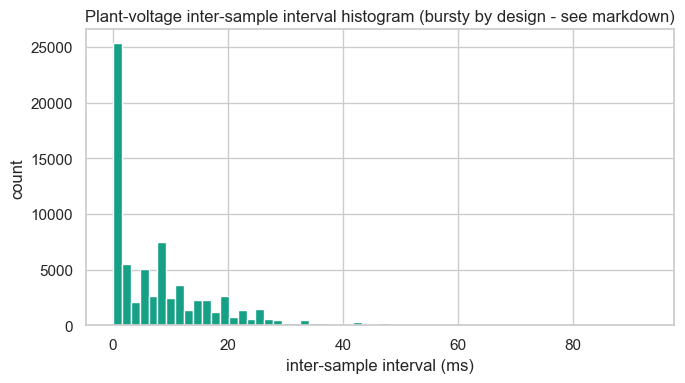

In [17]:
plant_events = sorted([e for e in events if e.get("sensor") == "plant_voltage"], key=lambda e: e["ts"])
plant_ts = np.array([e["ts"] for e in plant_events], dtype=np.int64)
plant_val = np.array([e["value"] for e in plant_events], dtype=float)
dt_ms = np.diff(plant_ts).astype(float)

# Throughput-based measurement (samples / total span), robust to bursty
# packet delivery - see markdown above for why a raw median of consecutive
# gaps is not usable here.
plant_span_s = (plant_ts[-1] - plant_ts[0]) / 1000.0 if plant_ts.size > 1 else np.nan
measured_fs = (plant_ts.size - 1) / plant_span_s if plant_ts.size > 1 else np.nan
deviation = abs(measured_fs - PLANT_FS_NOMINAL_HZ) / PLANT_FS_NOMINAL_HZ

print(f"Plant samples             : {plant_ts.size}")
print(f"Plant signal span         : {plant_span_s:.1f} s (session duration: {SESSION_DURATION_S:.1f} s)")
print(f"Measured sampling rate    : {measured_fs:.2f} Hz (samples / span)")
print(f"Configured nominal rate   : {PLANT_FS_NOMINAL_HZ:.2f} Hz")
print(f"Deviation                 : {100*deviation:.1f}% (tolerance {100*PLANT_FS_TOLERANCE:.0f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dt_ms, bins=60, color="#16a085")
ax.set_xlabel("inter-sample interval (ms)"); ax.set_ylabel("count")
ax.set_title("Plant-voltage inter-sample interval histogram (bursty by design - see markdown)")
plt.tight_layout(); plt.show()

if deviation > PLANT_FS_TOLERANCE:
    raise RuntimeError(
        f"Measured plant sampling rate ({measured_fs:.2f} Hz) deviates from the configured "
        f"nominal ({PLANT_FS_NOMINAL_HZ:.2f} Hz) by {100*deviation:.1f}%, exceeding the "
        f"{100*PLANT_FS_TOLERANCE:.0f}% tolerance. Refusing to window the plant signal at a "
        "rate that does not match what was actually measured - update PLANT_FS_NOMINAL_HZ only "
        "after confirming which rate is correct for this session/firmware version.")
PLANT_TRUE_FS = measured_fs

**CO2, environment only - not a label input.** The setup also streams
ambient CO2 (ppm) alongside the plant voltage. It is not used anywhere in
the label rule or the ML export; it is plotted in Section 4.11 purely as
context for reading the plant-voltage timeline (e.g. a rising CO2 trace
from the participant's own breathing in a small room is a plausible
confound for slow plant-voltage drift, and is worth being able to see).

In [18]:
co2_events = sorted([e for e in events if e.get("sensor") == "co2"], key=lambda e: e["ts"])
co2_ts = np.array([e["ts"] for e in co2_events], dtype=np.int64)
co2_val = np.array([e["value"] for e in co2_events], dtype=float)
if co2_ts.size:
    print(f"CO2 samples: {co2_ts.size}  range: {co2_val.min():.0f}-{co2_val.max():.0f} ppm  "
          f"mean: {co2_val.mean():.0f} ppm")
else:
    print("No co2 events in this session - CO2 row will be omitted from the timeline plot.")

CO2 samples: 1430  range: 759-778 ppm  mean: 766 ppm


In [19]:
_trapz = getattr(np, "trapezoid", None) or np.trapz

def extract_plant_features(volts, fs=None):
    fs = fs if fs is not None else PLANT_TRUE_FS
    out = {}
    v = np.asarray(volts, dtype=float)
    n = v.size
    out["plant_n_samples"] = int(n)

    if n == 0:
        for k in ["plant_mean", "plant_median", "plant_std", "plant_iqr", "plant_min", "plant_max",
                  "plant_range", "plant_rms", "plant_zcr", "plant_sat_pos_frac", "plant_sat_neg_frac",
                  "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum"]:
            out[k] = np.nan
        out["plant_const_flag"] = False
        out["plant_quality"] = "dead_flat"
        out["plant_dead_flag"] = True
        out["plant_suspect_flag"] = False
        return out

    # ── Mains notch (50 Hz), time-domain stats only ──────────────────────
    # ~49-50Hz carries 66-73% of the raw signal's total power on every real
    # session checked (see markdown above) - a plant_std computed on the raw
    # signal is mostly a mains-hum statistic, not a plant one. We remove it
    # here, before any time-domain stat is computed, with a zero-phase
    # filter (sosfiltfilt) so it does not shift sample values in time.
    # Saturation diagnostics below deliberately stay on the untouched raw
    # signal - a linear notch filter is not trustworthy right at the ADC
    # rails - and the spectral computation further below also stays on the
    # raw-derived signal, since Welch needs to see the real spectrum
    # (including the 30-50Hz band we deliberately drop) to be faithful.
    if n >= 32 and fs and fs > 2 * MAINS_HZ + 4:
        _sos = sp_signal.butter(4, [MAINS_HZ - 4, MAINS_HZ + 4], btype="bandstop", fs=fs, output="sos")
        v_td = sp_signal.sosfiltfilt(_sos, v)
    else:
        v_td = v

    mean = float(np.mean(v_td)); median = float(np.median(v_td))
    std = float(np.std(v_td, ddof=1)) if n > 1 else 0.0
    q75, q25 = np.percentile(v_td, [75, 25]); iqr = float(q75 - q25)
    vmin, vmax = float(np.min(v_td)), float(np.max(v_td)); rng_ = float(vmax - vmin)
    rms = float(np.sqrt(np.mean(v_td ** 2)))
    vd_td = v_td - mean
    zcr = float(np.mean(np.abs(np.diff(np.sign(vd_td))) > 0)) if n > 1 else 0.0
    out.update(plant_mean=round(mean, 6), plant_median=round(median, 6), plant_std=round(std, 6),
               plant_iqr=round(iqr, 6), plant_min=round(vmin, 6), plant_max=round(vmax, 6),
               plant_range=round(rng_, 6), plant_rms=round(rms, 6), plant_zcr=round(zcr, 6))

    # Saturation diagnostics: raw signal, deliberately not notch-filtered.
    sat_pos = float(np.mean(v >= ADC_VREF - 1e-3)); sat_neg = float(np.mean(v <= 1e-3))
    out.update(plant_sat_pos_frac=round(sat_pos, 4), plant_sat_neg_frac=round(sat_neg, 4),
               plant_const_flag=bool(np.all(v == v[0])))

    # Spectral: raw-derived, unaffected by the notch above.
    vd = v - float(np.mean(v))
    if n >= 16 and float(np.std(v)) > 0:
        nper = min(256, n)
        f, pxx = sp_signal.welch(vd, fs=fs, window="hann", nperseg=nper, scaling="density")
        def band(lo, hi):
            m = (f >= lo) & (f < hi)
            return float(_trapz(pxx[m], f[m])) if m.any() else 0.0
        bp_0_1, bp_1_5, bp_5_15, bp_15_30 = band(0, 1), band(1, 5), band(5, 15), band(15, 30)
        # 30-50 Hz band intentionally dropped: sits on 50 Hz mains interference at this fs
        band_power_sum = bp_0_1 + bp_1_5 + bp_5_15 + bp_15_30
    else:
        bp_0_1 = bp_1_5 = bp_5_15 = bp_15_30 = band_power_sum = np.nan
    out.update(bp_0_1=bp_0_1, bp_1_5=bp_1_5, bp_5_15=bp_5_15, bp_15_30=bp_15_30,
               band_power_sum=band_power_sum)

    lsb = ADC_VREF / 4096.0
    std_counts = std / lsb if lsb else float("inf")
    if sat_pos > 0.95 or sat_neg > 0.95:
        q = "dead_saturated"
    elif std < PLANT_DEAD_VOLTAGE_THRESHOLD:
        q = "dead_flat"
    elif std_counts < 5:
        q = "dead_flat"
    elif (sat_pos + sat_neg) > 0.20:
        q = "suspect_clipped"
    elif std_counts < 10:
        q = "suspect_lowamp"
    else:
        q = "ok"
    out["plant_quality"] = q
    out["plant_dead_flag"] = q.startswith("dead")
    out["plant_suspect_flag"] = q.startswith("suspect")
    return out


def add_plant_features(df):
    rows = []
    for r in df.itertuples():
        m = (plant_ts >= r.win_start_ms) & (plant_ts < r.win_end_ms)
        rows.append(extract_plant_features(plant_val[m]))
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)


ml_df = add_plant_features(ml_df)
analysis_df = add_plant_features(analysis_df)

print("Plant quality distribution (ML grid):")
print(ml_df["plant_quality"].value_counts())

PLANT_COLS = ["plant_n_samples", "plant_mean", "plant_median", "plant_std", "plant_iqr", "plant_min",
              "plant_max", "plant_range", "plant_rms", "plant_zcr", "plant_sat_pos_frac",
              "plant_sat_neg_frac", "plant_const_flag", "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30",
              "band_power_sum", "plant_quality", "plant_dead_flag", "plant_suspect_flag"]

ml_export = finalize_export(ml_df, PARTICIPANT_ID, SESSION_ID)
ml_export = pd.concat([ml_export, ml_df[PLANT_COLS].reset_index(drop=True)], axis=1)
overlap_export = finalize_export(analysis_df, PARTICIPANT_ID, SESSION_ID)
overlap_export = pd.concat([overlap_export, analysis_df[PLANT_COLS].reset_index(drop=True)], axis=1)

ml_export.to_csv(OUT_ML_CSV, index=False)
overlap_export.to_csv(OUT_OVERLAP_CSV, index=False)
print(f"\nRe-saved with plant features: {OUT_ML_CSV} ({ml_export.shape[1]} columns), "
      f"{OUT_OVERLAP_CSV} ({overlap_export.shape[1]} columns)")

Plant quality distribution (ML grid):
plant_quality
ok                19
suspect_lowamp     1
Name: count, dtype: int64

Re-saved with plant features: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions\2026-07-06_19-14_proband_13\labelled_windows_ml.csv (49 columns), C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\sessions\2026-07-06_19-14_proband_13\labelled_windows_overlapping.csv (48 columns)


## 4.11 Visualisation

A session timeline (RMSSD, HR, FER valence, HRV-based arousal, plant
voltage with CO2 overlaid, and three label bars — valence, arousal, and the
crossed emotion label), a decision-space scatter of FER valence x HRV
arousal coloured by the emotion label (with each axis's deadband edges
marked), the composition of all three label columns, and the confidence
distribution.

The plant-voltage row uses the anti-aliased 1 Hz signal from §4.10 for
display only — the per-window features used for the ML export are computed
on the raw, undecimated signal, so this choice only affects what the plot
looks like.


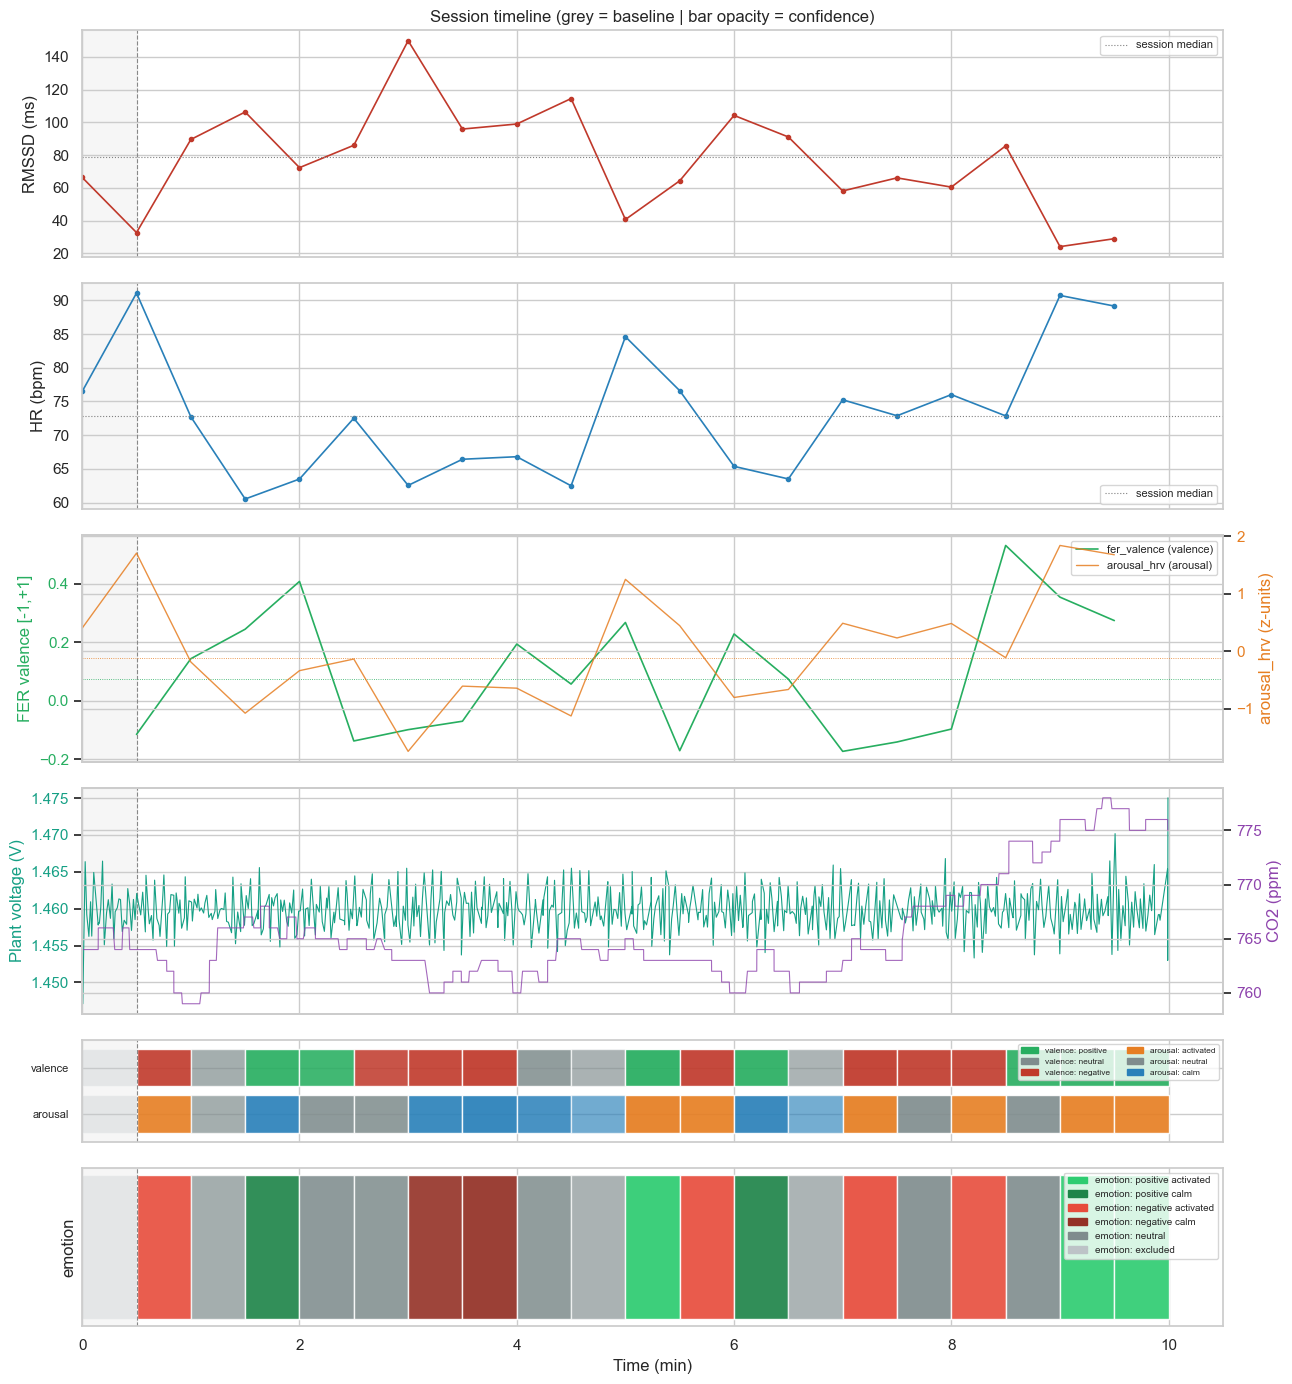

In [20]:
# ── Anti-aliased 1 Hz plant-voltage grid, for the timeline plot only ────
# resample_poly(up=1, down=_down) maps output sample k to (approximately)
# input sample k*_down; we read the REAL timestamp of that input sample
# directly rather than assuming a constant rate, so the time axis is
# correct even though the raw stream arrives in bursts (§4.10).
# padtype="line" (default is "constant", i.e. zero-padding): the plant
# voltage sits around 1.4 V, nowhere near zero, so zero-padding the FIR
# filter's edges pulls the first/last decimated samples down toward 0 V -
# a filter artefact, not a real reading. "line" extrapolates from the
# signal's own edge trend instead, which keeps the endpoints physical.
_down = max(1, int(round(PLANT_TRUE_FS)))
if plant_val.size > _down * 2:
    plant_1hz = sp_signal.resample_poly(plant_val, up=1, down=_down, padtype="line")
    _out_idx = np.clip(np.arange(plant_1hz.size) * _down, 0, plant_val.size - 1)
    plant_1hz_t_s = (plant_ts[_out_idx] - T0_MS) / 1000.0
else:
    plant_1hz, plant_1hz_t_s = plant_val, (plant_ts - T0_MS) / 1000.0

# Colour maps for all three label columns - the emotion map is unchanged;
# the valence/arousal maps below share the "negative/calm = red-ish family,
# positive/activated = green-ish family, neutral = grey" convention so the
# three bars in the timeline read consistently top to bottom.
label_col = {"positive activated": "#2ecc71", "positive calm": "#1e8449",
             "negative activated": "#e74c3c", "negative calm": "#943126",
             "neutral": "#7f8c8d", "excluded": "#bdc3c7"}
valence_col = {"positive": "#27ae60", "neutral": "#7f8c8d", "negative": "#c0392b",
               "excluded": "#bdc3c7"}
arousal_col = {"activated": "#e67e22", "neutral": "#7f8c8d", "calm": "#2980b9",
               "excluded": "#bdc3c7"}

fig, axes = plt.subplots(6, 1, figsize=(13, 14), sharex=True,
                          gridspec_kw={"height_ratios": [2, 2, 2, 2, 0.9, 1.4]})

def t_min(ts_array):
    return (np.asarray(ts_array) - T0_MS) / 60_000

for ax in axes:
    ax.axvspan(0, BASELINE_S / 60, alpha=0.10, color="#aaaaaa", zorder=0)
    ax.axvline(BASELINE_S / 60, color="#888", lw=0.8, ls="--")

axes[0].plot(t_min(ml_df.win_start_ms), ml_df.rmssd, color="#c0392b", lw=1.2, marker="o", ms=3)
axes[0].axhline(CALIB["median_rmssd"], color="gray", lw=0.8, ls=":", label="session median")
axes[0].set_ylabel("RMSSD (ms)"); axes[0].legend(fontsize=8)
axes[0].set_title("Session timeline (grey = baseline | bar opacity = confidence)")

axes[1].plot(t_min(ml_df.win_start_ms), ml_df.mean_hr, color="#2980b9", lw=1.2, marker="o", ms=3)
axes[1].axhline(CALIB["median_hr"], color="gray", lw=0.8, ls=":", label="session median")
axes[1].set_ylabel("HR (bpm)"); axes[1].legend(fontsize=8)

# The two quantities that actually decide the label: fer_valence (valence
# axis) on the left, arousal_hrv (arousal axis) on the right - deliberately
# not the raw fer_arousal, since that is not read by the label rule at all.
ax2b = axes[2].twinx()
axes[2].plot(t_min(ml_df.win_start_ms), ml_df.fer_valence, color="#27ae60", lw=1.2,
             label="fer_valence (valence)")
axes[2].axhline(CALIB["median_fer_valence"], color="#27ae60", lw=0.6, ls=":")
axes[2].set_ylabel("FER valence [-1,+1]", color="#27ae60")
axes[2].tick_params(axis="y", labelcolor="#27ae60")

ax2b.plot(t_min(ml_df.win_start_ms), ml_df.arousal_hrv, color="#e67e22", lw=1.0, alpha=0.85,
          label="arousal_hrv (arousal)")
ax2b.axhline(CALIB["median_arousal_hrv"], color="#e67e22", lw=0.6, ls=":")
ax2b.set_ylabel("arousal_hrv (z-units)", color="#e67e22")
ax2b.tick_params(axis="y", labelcolor="#e67e22")

_l2, _lab2 = axes[2].get_legend_handles_labels()
_l2b, _lab2b = ax2b.get_legend_handles_labels()
axes[2].legend(_l2 + _l2b, _lab2 + _lab2b, fontsize=8, loc="upper right")

axes[3].plot(plant_1hz_t_s / 60, plant_1hz, color="#16a085", lw=0.8, label="plant voltage")
axes[3].set_ylabel("Plant voltage (V)", color="#16a085")
axes[3].tick_params(axis="y", labelcolor="#16a085")
if co2_ts.size:
    ax3b = axes[3].twinx()
    ax3b.plot(t_min(co2_ts), co2_val, color="#8e44ad", lw=0.8, alpha=0.8, label="CO2")
    ax3b.set_ylabel("CO2 (ppm)", color="#8e44ad")
    ax3b.tick_params(axis="y", labelcolor="#8e44ad")

# Three thin label bars, stacked: valence_direction, arousal_level, and the
# crossed emotion label - same barh/opacity-by-confidence convention as
# before, just repeated once per label column so the two component axes
# are visible right above the label they combine into.
for r in ml_df.itertuples():
    ts = (r.win_start_ms - T0_MS) / 60_000
    axes[4].barh(1, WIN_S / 60, left=ts, height=0.8, color=valence_col.get(r.valence_direction, "#bdc3c7"),
                 alpha=0.3 + 0.7 * r.label_confidence)
    axes[4].barh(0, WIN_S / 60, left=ts, height=0.8, color=arousal_col.get(r.arousal_level, "#bdc3c7"),
                 alpha=0.3 + 0.7 * r.label_confidence)
axes[4].set_yticks([0, 1]); axes[4].set_yticklabels(["arousal", "valence"], fontsize=8)
axes[4].set_ylim(-0.6, 1.6)

for r in ml_df.itertuples():
    ts = (r.win_start_ms - T0_MS) / 60_000
    axes[5].barh(0, WIN_S / 60, left=ts, height=0.8, color=label_col.get(r.label, "#bdc3c7"),
                 alpha=0.3 + 0.7 * r.label_confidence)
axes[5].set_yticks([]); axes[5].set_ylabel("emotion"); axes[5].set_xlabel("Time (min)")

_valence_patches = [mpatches.Patch(color=c, label=f"valence: {l}") for l, c in valence_col.items()]
_arousal_patches = [mpatches.Patch(color=c, label=f"arousal: {l}") for l, c in arousal_col.items()]
_label_patches = [mpatches.Patch(color=c, label=f"emotion: {l}") for l, c in label_col.items()]
axes[4].legend(handles=_valence_patches[:3] + _arousal_patches[:3], loc="upper right", fontsize=6, ncol=2)
axes[5].legend(handles=_label_patches, loc="upper right", fontsize=7)

plt.tight_layout(); plt.show()


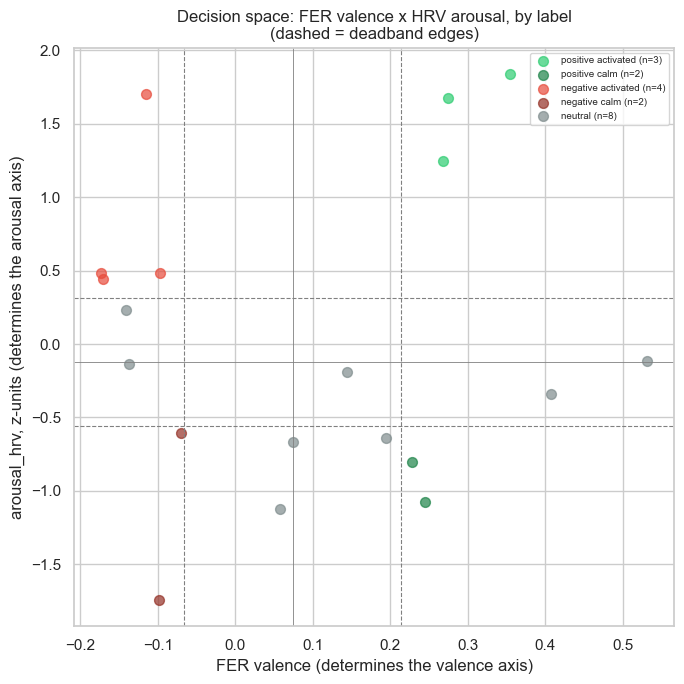

In [21]:
# ── Decision-space scatter: FER valence x HRV arousal ───────────────────
# Not a facial-only Russell circumplex anymore - the y-axis is arousal_hrv
# (the actual arousal determinant, §4.7), not fer_arousal. Dashed lines mark
# each axis's deadband edge (median ± tau), so the four quadrant regions and
# the cross-shaped "neutral" band are visible directly.
fig, ax = plt.subplots(figsize=(7, 7))
for lab, c in label_col.items():
    if lab == "excluded":
        continue
    sub = ml_df[ml_df.label == lab]
    if len(sub):
        ax.scatter(sub["fer_valence"], sub["arousal_hrv"], color=c, alpha=0.7, s=50,
                   label=f"{lab} (n={len(sub)})")

med_v, tau = CALIB["median_fer_valence"], CALIB["tau"]
med_a, tau_a = CALIB["median_arousal_hrv"], CALIB["tau_arousal"]
ax.axvline(med_v, color="gray", lw=0.6)
ax.axvline(med_v + tau, color="gray", lw=0.8, ls="--")
ax.axvline(med_v - tau, color="gray", lw=0.8, ls="--")
ax.axhline(med_a, color="gray", lw=0.6)
ax.axhline(med_a + tau_a, color="gray", lw=0.8, ls="--")
ax.axhline(med_a - tau_a, color="gray", lw=0.8, ls="--")
ax.set_xlabel("FER valence (determines the valence axis)")
ax.set_ylabel("arousal_hrv, z-units (determines the arousal axis)")
ax.set_title("Decision space: FER valence x HRV arousal, by label\n(dashed = deadband edges)")
ax.legend(fontsize=7, loc="best"); plt.tight_layout(); plt.show()


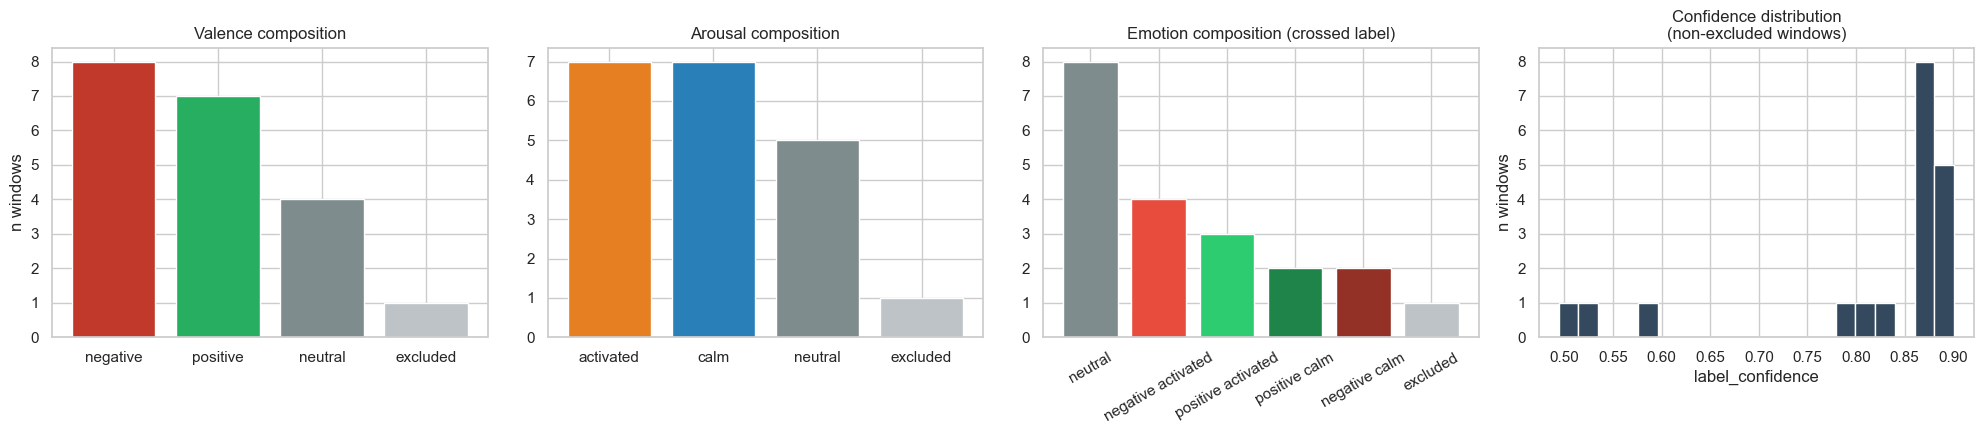

In [22]:
# ── Label composition (all three columns) + confidence distribution ─────
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

val_counts = ml_df["valence_direction"].value_counts()
axes[0].bar(val_counts.index, val_counts.values,
            color=[valence_col.get(l, "#bdc3c7") for l in val_counts.index])
axes[0].set_ylabel("n windows"); axes[0].set_title("Valence composition")

aro_counts = ml_df["arousal_level"].value_counts()
axes[1].bar(aro_counts.index, aro_counts.values,
            color=[arousal_col.get(l, "#bdc3c7") for l in aro_counts.index])
axes[1].set_title("Arousal composition")

counts = ml_df["label"].value_counts()
axes[2].bar(counts.index, counts.values, color=[label_col.get(l, "#bdc3c7") for l in counts.index])
axes[2].tick_params(axis="x", labelrotation=30)
axes[2].set_title("Emotion composition (crossed label)")

axes[3].hist(ml_df.loc[ml_df.label != "excluded", "label_confidence"], bins=20, color="#34495e")
axes[3].set_xlabel("label_confidence"); axes[3].set_ylabel("n windows")
axes[3].set_title("Confidence distribution\n(non-excluded windows)")

plt.tight_layout(); plt.show()


## 4.12 Limitations

- **No self-report.** This is a **proxy label**, not ground truth — its
  accuracy against what the participant actually felt is unknown. The
  standard fix would be Self-Assessment Manikin ratings (Bradley & Lang,
  1994) collected during or after the session; this notebook doesn't
  implement that.
- **Facial expression can be suppressed.** Valence comes entirely from the
  face — a participant who felt something without showing it is labelled
  `"neutral"`, not "wrong".
- **HSEmotion is an imperfect direction estimator** (61.93% accuracy on
  AffectNet, 8-class) — a reasonable but not reliable single-window
  classifier.
- **The arousal axis rests entirely on a signal the literature calls weak
  and contested.** RMSSD + mean HR are the *sole* determinant of arousal,
  with no facial fallback. Schippers et al. (2018), using the same design
  as this notebook, found no valence-related RMSSD difference at all, and
  Gu et al. (2023) found ultra-short-window HRV often misses real
  condition differences. This was a deliberate design choice, not a claim
  that HRV alone is a strong arousal indicator — treat `arousal_level`
  with matching scepticism.
- **Respiration was not recorded**, and shifts in breathing change RMSSD
  without changing vagal tone (Shaffer & Ginsberg, 2017) — the largest
  uncontrolled confounder on the arousal axis.
- **Ultra-short-term HRV (30 s) is not interchangeable with the 5-min or
  24-h HRV most literature reports** (Shaffer & Ginsberg, 2017).
- **No stimulus-based or between-participant validation.** The pipeline
  ignores video-clip timing, so it can't check whether different
  participants reacted the same way to the same moment — the strongest
  test this kind of data could support isn't available here.
- **The plant-voltage channel's physiological validity could not be
  confirmed, and this is now permanent** — the hardware is no longer
  available to re-test. Real sessions were dominated by mains
  interference (§4.10); the notch filter removes that specifically but
  cannot confirm what's left over is genuine plant physiology rather than
  proximity interference.
- **Small sample.** Session counts here are small; nothing above supports
  strong generalisation claims.
- **Pragmatic parameters.** `K_TAU`, `AROUSAL_K_TAU`, and the confidence
  weights `W1..W4` are engineering choices, not literature values. Both
  deadbands are sized off the session's own median/MAD, so changing them
  and re-running from §4.7 is the direct way to see their effect.


## 4.13 References

1. Task Force of the European Society of Cardiology and the North American
   Society of Pacing and Electrophysiology (1996). Heart rate variability:
   standards of measurement, physiological interpretation, and clinical use.
   *Circulation*, 93(5), 1043-1065.
2. Shaffer, F., & Ginsberg, J. P. (2017). An Overview of Heart Rate
   Variability Metrics and Norms. *Frontiers in Public Health*, 5, 258.
   doi:10.3389/fpubh.2017.00258
3. Baek, H. J., Cho, C.-H., Cho, J., & Woo, J.-M. (2015). Reliability of
   Ultra-Short-Term Analysis as a Surrogate of Standard 5-Min Analysis of
   Heart Rate Variability. *Telemedicine and e-Health*, 21(5), 404-414.
   doi:10.1089/tmj.2014.0104
4. Kreibig, S. D. (2010). Autonomic nervous system activity in emotion: A
   review. *Biological Psychology*, 84(3), 394-421.
   doi:10.1016/j.biopsycho.2010.03.010
5. Schneider, M., Rominger, C., & Schwerdtfeger, A. R. (2025). Associations
   Between Positive Affect and Heart Rate Variability: A Systematic Review.
   *Current Cardiology Reports*. doi:10.1007/s11886-025-02299-4
6. Russell, J. A. (1980). A circumplex model of affect. *Journal of
   Personality and Social Psychology*, 39(6), 1161-1178.
7. Mollahosseini, A., Hasani, B., & Mahoor, M. H. (2019). AffectNet: A
   Database for Facial Expression, Valence, and Arousal Computing in the
   Wild. *IEEE Transactions on Affective Computing*, 10(1), 18-31.
   doi:10.1109/TAFFC.2017.2740923
8. Savchenko, A. V. (2022). HSEmotion: High-speed emotion recognition
   library. *Software Impacts*, 5, 100433. doi:10.1016/j.simpa.2022.100433
9. Savchenko, A. V. (2022). Frame-level Prediction of Facial Expressions,
   Valence, Arousal and Action Units for Mobile Devices. arXiv:2203.13436
   (CVPR 2022 ABAW Workshop).
10. EmotiEffLib (ex-HSEmotion) repository, model table under "Details":
    github.com/sb-ai-lab/EmotiEffLib
11. Soleymani, M., Asghari-Esfeden, S., Fu, Y., & Pantic, M. (2016).
    Analysis of EEG Signals and Facial Expressions for Continuous Emotion
    Detection. *IEEE Transactions on Affective Computing*, 7(1), 17-28.
12. Lipponen, J. A., & Tarvainen, M. P. (2019). A robust algorithm for heart
    rate variability time series artefact correction using novel beat
    classification. *Journal of Medical Engineering & Technology*, 43(3),
    173-181. doi:10.1080/03091902.2019.1640306
13. Makowski, D., Pham, T., Lau, Z. J., Brammer, J. C., Lespinasse, F., Pham,
    H., Scholzel, C., & Chen, S. H. A. (2021). NeuroKit2: A Python toolbox
    for neurophysiological signal processing. *Behavior Research Methods*,
    53(4), 1689-1696.
14. Gilgen-Ammann, R., Schweizer, T., & Wyss, T. (2019). RR interval signal
    quality of a heart rate monitor and an ECG Holter at rest and during
    exercise. *European Journal of Applied Physiology*, 119(7), 1525-1532.
    doi:10.1007/s00421-019-04142-5
15. Schaffarczyk, M., Rogers, B., Reer, R., & Gronwald, T. (2022). Validity
    of the Polar H10 Sensor for Heart Rate Variability Analysis during
    Resting State and Incremental Exercise in Recreational Men and Women.
    *Sensors*, 22(17), 6536. doi:10.3390/s22176536
16. Bradley, M. M., & Lang, P. J. (1994). Measuring emotion: The
    Self-Assessment Manikin and the semantic differential. *Journal of
    Behavior Therapy and Experimental Psychiatry*, 25(1), 49-59.
    doi:10.1016/0005-7916(94)90063-9
17. Schippers, A., Aben, B., Griep, Y., & Van Overwalle, F. (2018).
    Ultra-short term heart rate variability as a tool to assess changes in
    valence. *Psychiatry Research*, 270, 517-522.
    doi:10.1016/j.psychres.2018.10.005
18. Gu, Z., Zarubin, V., & Martsberger, C. (2023). The effectiveness of time
    domain and nonlinear heart rate variability metrics in ultra-short time
    series. *Physiological Reports*, 11(22), e15863. doi:10.14814/phy2.15863
